In [3]:
import sys
from pathlib import Path

_root = next(p for p in Path.cwd().resolve().parents if (p / '.git').exists() or (p / 'setup.py').exists())
for _p in (str(_root), str(_root / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import scanpy as sc
import gseapy as gp
from metab_processing.metab_travlr_config import DATA_DIR
from metab_processing.SpaceTravLR.dataset_configs import dataset_paths
from metab_processing.LinearRegression.build_x import add_gene_signature
from metab_processing.LinearRegression.least_squares import (
    fit_gene_betas, subsample_gene_betas, rank_coefficients,
    plot_top_coefficients, plot_beta_histogram)

dataset = 'Primary_Dermal_Melanoma'
data_dir = f'{DATA_DIR}/Xenium'
ANNOT_COL, CELL_TYPE = 'Tier1', 'T Cell'
METHOD, PENALTY, STANDARDIZE = 'l1', 0.05, True
N_SUB = 50
LOWER, UPPER = 15, 85
DBVER = '2024.1.Hs'

SIGNATURES = [
    # T cell biology
    'HALLMARK_IL2_STAT5_SIGNALING',
    'KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY',
    'GOBP_T_CELL_MEDIATED_CYTOTOXICITY',
    'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE',
    # Metabolic
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_GLYCOLYSIS',
    'HALLMARK_HYPOXIA',
    'HALLMARK_FATTY_ACID_METABOLISM',
    'HALLMARK_MTORC1_SIGNALING',
    # Negative control
    'HALLMARK_PANCREAS_BETA_CELLS',
]

In [4]:
paths = dataset_paths(dataset, data_dir=data_dir)
adata = sc.read_h5ad(paths['dataset_dir'] / 'LinearRegression' / 'x_adata.h5ad')
var = set(adata.var_names)
print(adata.n_obs, 'cells |', len(adata.uns['x_genes']), 'built genes')

112551 cells | 697 built genes


In [5]:
# Fetch the gene sets, print each, and report which genes are absent from the data.
msig = gp.Msigdb()
library = {}
for cat in ('h.all', 'c2.cp.kegg_legacy', 'c5.go.bp'):
    try:
        library.update(msig.get_gmt(category=cat, dbver=DBVER) or {})
    except Exception as e:
        print(f'{cat}: FAILED ({e})')

sets = {}        # name -> genes PRESENT in adata (what each pseudo-gene is built from)
for name in SIGNATURES:
    genes = library.get(name)
    if genes is None:
        print(f'MISSING SET (name not found in MSigDB): {name}')
        continue
    present = [g for g in genes if g in var]
    absent = [g for g in genes if g not in var]
    sets[name] = present
    print(f'{name}: {len(present)}/{len(genes)} genes present'
          + (f'  | missing: {absent}' if absent else ''))

HALLMARK_IL2_STAT5_SIGNALING: 122/199 genes present  | missing: ['ADAM19', 'AHNAK', 'ANXA4', 'APLP1', 'ARL4A', 'BHLHE40', 'CA2', 'CAPG', 'CD48', 'CD81', 'CDC42SE2', 'CISH', 'COL6A1', 'CTSZ', 'CYFIP1', 'DCPS', 'DENND5A', 'DHRS3', 'ECM1', 'EEF1AKMT1', 'ENO3', 'ETFBKMT', 'ETV4', 'F2RL2', 'FAH', 'FGL2', 'GABARAPL1', 'GADD45B', 'GALM', 'GBP4', 'GPR65', 'GPX4', 'GUCY1B1', 'HYCC2', 'IFITM3', 'IL1R2', 'IRF6', 'KLF6', 'LCLAT1', 'LRIG1', 'LRRC8C', 'LTB', 'MAP3K8', 'MAP6', 'NFIL3', 'NFKBIZ', 'ODC1', 'PDCD2L', 'PHLDA1', 'PHTF2', 'PLPP1', 'PRAF2', 'PTRH2', 'PUS1', 'RABGAP1L', 'RGS16', 'RHOB', 'RNH1', 'RORA', 'RRAGD', 'SERPINB6', 'SHE', 'SLC29A2', 'SMPDL3A', 'SNX14', 'SNX9', 'SPP1', 'SPRED2', 'SPRY4', 'ST3GAL4', 'SWAP70', 'SYNGR2', 'SYT11', 'TNFRSF4', 'TTC39B', 'UCK2', 'WLS']
KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY: 80/108 genes present  | missing: ['CBLC', 'CD3D', 'CHP1', 'CHP2', 'FOS', 'GRAP2', 'JUN', 'LCP2', 'MAP2K2', 'MAP2K7', 'MAP3K8', 'MAPK13', 'NCK2', 'NFKBIA', 'NFKBIB', 'NFKBIE', 'PAK3', 'PAK

In [6]:
for name in sets.keys():
    print(f'{name}: Present genes: {sets[name]}')

HALLMARK_IL2_STAT5_SIGNALING: Present genes: ['ABCB1', 'AGER', 'AHCY', 'AHR', 'ALCAM', 'AMACR', 'BATF', 'BATF3', 'BCL2', 'BCL2L1', 'BMP2', 'BMPR2', 'CAPN3', 'CASP3', 'CCND2', 'CCND3', 'CCNE1', 'CCR4', 'CD44', 'CD79B', 'CD83', 'CD86', 'CDC6', 'CDCP1', 'CDKN1C', 'CKAP4', 'COCH', 'CSF1', 'CSF2', 'CST7', 'CTLA4', 'CXCL10', 'DRC1', 'EMP1', 'ENPP1', 'EOMES', 'FLT3LG', 'FURIN', 'GATA1', 'GLIPR2', 'GPR83', 'GSTO1', 'HIPK2', 'HK2', 'HOPX', 'HUWE1', 'ICOS', 'IFNGR1', 'IGF1R', 'IGF2R', 'IKZF2', 'IKZF4', 'IL10', 'IL10RA', 'IL13', 'IL18R1', 'IL1RL1', 'IL2RA', 'IL2RB', 'IL3RA', 'IL4R', 'IRF4', 'IRF8', 'ITGA6', 'ITGAE', 'ITGAV', 'ITIH5', 'LIF', 'MAFF', 'MAPKAPK2', 'MUC1', 'MXD1', 'MYC', 'MYO1C', 'MYO1E', 'NCOA3', 'NCS1', 'NDRG1', 'NOP2', 'NRP1', 'NT5E', 'P2RX4', 'P4HA1', 'PENK', 'PIM1', 'PLAGL1', 'PLEC', 'PLIN2', 'PLSCR1', 'PNP', 'POU2F1', 'PRKCH', 'PRNP', 'PTCH1', 'PTGER2', 'PTH1R', 'RHOH', 'S100A1', 'SCN9A', 'SELL', 'SELP', 'SERPINC1', 'SH3BGRL2', 'SLC1A5', 'SLC2A3', 'SLC39A8', 'SOCS1', 'SOCS2', 'T

In [7]:
sets['HALLMARK_INTERFERON_GAMMA_RESPONSE'] = [x for x in sets['HALLMARK_INTERFERON_GAMMA_RESPONSE'] if x not in {'STAT1', 'IRF1', 'STAT2', 'STAT3', 'STAT4', 'IRF4', 'IRF7', 'NFKB1', 'FAS', 'IL15'}]

In [8]:
print(sets['HALLMARK_INTERFERON_GAMMA_RESPONSE'])

['ADAR', 'APOL6', 'BANK1', 'CASP1', 'CASP3', 'CASP7', 'CASP8', 'CCL7', 'CD274', 'CD38', 'CD40', 'CD86', 'CDKN1A', 'CFB', 'CFH', 'CIITA', 'CMKLR1', 'CSF2RB', 'CXCL10', 'CXCL11', 'CXCL9', 'EIF2AK2', 'FCGR1A', 'FPR1', 'GCH1', 'GZMA', 'HERC6', 'HIF1A', 'ICAM1', 'IDO1', 'IFI35', 'IFI44L', 'IFIH1', 'IFIT1', 'IFIT2', 'IFIT3', 'IFNAR2', 'IL10RA', 'IL15RA', 'IL18BP', 'IL2RB', 'IL4R', 'IL6', 'IL7', 'IRF5', 'IRF8', 'ITGB7', 'JAK2', 'KLRK1', 'LATS2', 'MVP', 'MX1', 'MYD88', 'NCOA3', 'NLRC5', 'NOD1', 'NUP93', 'OAS3', 'OGFR', 'P2RY14', 'PDE4B', 'PFKP', 'PIM1', 'PLA2G4A', 'PLSCR1', 'PML', 'PNP', 'PNPT1', 'PTGS2', 'PTPN1', 'PTPN2', 'PTPN6', 'RAPGEF6', 'RBCK1', 'RIPK1', 'RIPK2', 'RNF31', 'RSAD2', 'SAMHD1', 'SELP', 'SLAMF7', 'SOCS1', 'SOCS3', 'SP110', 'SPPL2A', 'SRI', 'TAP1', 'TDRD7', 'TNFSF10', 'TRAFD1', 'TRIM21', 'TRIM25', 'VAMP5', 'VCAM1', 'ZBP1']


In [9]:
def add_subsample_percentiles(betas_df, sub, lower=LOWER, upper=UPPER):
    """Add min/max and lower/upper-percentile subsample-beta columns to betas_df,
    matched by factor (`sub` = n_subsamples x factor DataFrame from subsample_gene_betas)."""
    out = betas_df.copy()
    def stat(fn):
        return [fn(sub[f]) if f in sub.columns else np.nan for f in out['factor']]
    out['min_subsample_beta'] = stat(np.nanmin)
    out['max_subsample_beta'] = stat(np.nanmax)
    out[f'lower_{lower}_subsample_beta'] = stat(lambda s: np.nanpercentile(s, lower))
    out[f'upper_{upper}_subsample_beta'] = stat(lambda s: np.nanpercentile(s, upper))
    return out

In [10]:
def run_signature(name, penalty=PENALTY, n_sub=N_SUB, lower=LOWER, upper=UPPER, top=15):
    """All-positive pseudo-gene for `name` -> fit (L1/standardized) -> resample -> ranked
    betas with subsample-percentile columns. Prints a table + a top-coefficients plot.
    Returns (betas_with_percentiles, sub)."""
    if name not in sets:
        print(f'skip {name}: set not available'); return None, None
    genes = sets[name]
    ad2 = add_gene_signature(adata, name, positive=genes)   # negative=[] (all positive)
    b = fit_gene_betas(ad2, genes=[name], annot_col=ANNOT_COL, metabolites=[], annot_value=CELL_TYPE,
                       method=METHOD, penalty=penalty, standardize=STANDARDIZE)
    sub = subsample_gene_betas(ad2, name, factors=None, n_subsamples=n_sub,
                               annot_col=ANNOT_COL, annot_value=CELL_TYPE,
                               method=METHOD, penalty=penalty, standardize=STANDARDIZE)
    res = add_subsample_percentiles(rank_coefficients(b), sub, lower, upper)
    print(f'=== {name}: {len(genes)} genes present ===')
    display(res.head(60))
    if not res.empty:
        plot_top_coefficients(b, top=top).set_title(name)
    return res, sub

## T cell biology

=== HALLMARK_IL2_STAT5_SIGNALING: 122 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
484,HALLMARK_IL2_STAT5_SIGNALING,LGALS9$CD44,lr,0.402852,0.405252,0.164229,0.787488,9364,0.332217,0.474596,0.373570,0.431234
2114,HALLMARK_IL2_STAT5_SIGNALING,XBP1,tf,0.373211,0.213576,0.045615,0.787488,9364,0.320731,0.422691,0.331097,0.378511
1572,HALLMARK_IL2_STAT5_SIGNALING,BATF,tf,0.365217,0.299433,0.089660,0.787488,9364,0.308051,0.415040,0.340920,0.390651
1154,HALLMARK_IL2_STAT5_SIGNALING,IRF4,tf,0.297786,0.308273,0.095032,0.787488,9364,0.233134,0.323897,0.246415,0.293542
2168,HALLMARK_IL2_STAT5_SIGNALING,HOXB7,tf,0.284454,0.315011,0.099232,0.787488,9364,0.191521,0.323397,0.221146,0.282943
396,HALLMARK_IL2_STAT5_SIGNALING,TNFSF9$TNFRSF9,lr,0.278610,0.246440,0.060733,0.787488,9364,0.190070,0.318238,0.219281,0.289713
137,HALLMARK_IL2_STAT5_SIGNALING,BMP8B$BMPR2,lr,0.269419,0.290849,0.084593,0.787488,9364,0.144441,0.331073,0.201255,0.259608
307,HALLMARK_IL2_STAT5_SIGNALING,IL15$IL2RB,lr,0.266391,0.268605,0.072148,0.787488,9364,0.208959,0.301648,0.230775,0.280649
561,HALLMARK_IL2_STAT5_SIGNALING,LAMC1$CD44,lr,0.196841,0.343927,0.118286,0.787488,9364,0.098509,0.215777,0.133176,0.193853
1468,HALLMARK_IL2_STAT5_SIGNALING,HMGA1,tf,0.193969,0.346913,0.120349,0.787488,9364,0.105135,0.230464,0.146975,0.189867


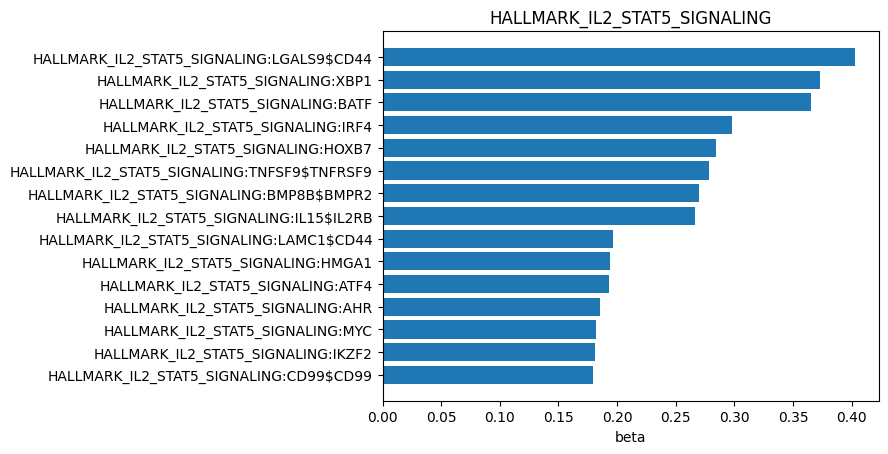

In [11]:
res_il2, sub_il2 = run_signature('HALLMARK_IL2_STAT5_SIGNALING')

=== KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY: 80 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
694,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,LCK$CD8A,lr,0.506890,0.327255,0.107096,0.697501,9364,0.426852,0.570833,0.479147,0.547349
391,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,IL16$CD4,lr,0.282290,0.265047,0.070250,0.697501,9364,0.192128,0.312987,0.233110,0.295170
1618,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,NFATC3,tf,0.279963,0.221323,0.048984,0.697501,9364,0.216436,0.315110,0.246544,0.296245
1947,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,EWSR1,tf,0.258783,0.367003,0.134691,0.697501,9364,0.186975,0.310046,0.226825,0.272394
1617,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,NFATC2,tf,0.252386,0.178241,0.031770,0.697501,9364,0.162417,0.305645,0.221849,0.273874
2385,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,ITGB2,tf,0.224502,0.342054,0.117001,0.697501,9364,0.153096,0.273945,0.189650,0.229548
79,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,RELA,tf,0.221065,0.219806,0.048315,0.697501,9364,0.171954,0.263891,0.190695,0.246510
1694,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,IKZF1,tf,0.206232,0.277511,0.077012,0.697501,9364,0.146009,0.243709,0.169733,0.224432
1696,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,IKZF3,tf,0.203741,0.227817,0.051901,0.697501,9364,0.168929,0.272169,0.183878,0.223112
334,KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY,IL7$IL2RG,lr,0.202063,0.309838,0.096000,0.697501,9364,0.128417,0.249800,0.159969,0.216649


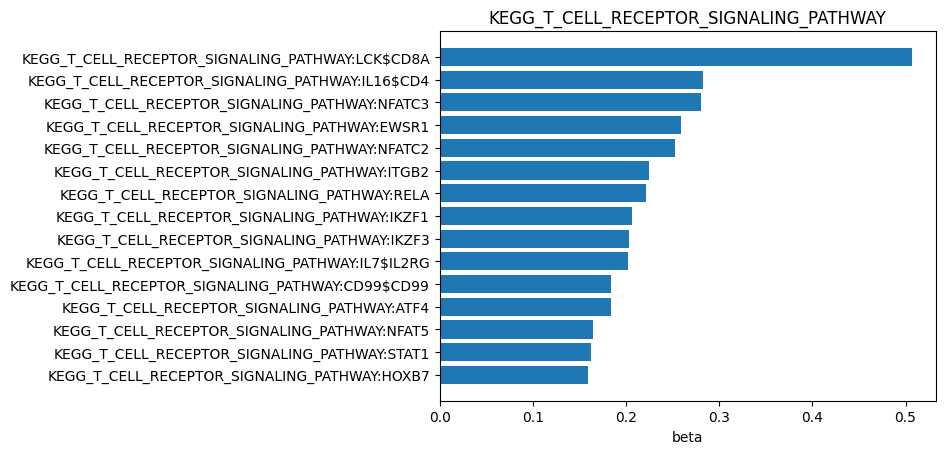

In [18]:
res_tcr, sub_tcr = run_signature('KEGG_T_CELL_RECEPTOR_SIGNALING_PATHWAY')

=== GOBP_T_CELL_MEDIATED_CYTOTOXICITY: 36 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
2026,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,ITGB2,tf,0.119662,0.307544,0.094583,0.473127,9364,0.079037,0.140141,0.096192,0.120393
889,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,STAT1,tf,0.106328,0.331892,0.110152,0.473127,9364,0.060674,0.114273,0.081213,0.105670
1732,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,ATF4,tf,0.095236,0.305410,0.093275,0.473127,9364,0.045109,0.123923,0.073046,0.099133
330,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,IL16$CD4,lr,0.089881,0.246184,0.060607,0.473127,9364,0.041268,0.095427,0.056540,0.084775
579,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,CD99$CD99,lr,0.087673,0.295641,0.087404,0.473127,9364,0.043740,0.104036,0.065705,0.088355
1594,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,EWSR1,tf,0.073319,0.294853,0.086938,0.473127,9364,0.038480,0.111974,0.052729,0.086051
277,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,IL15$IL2RG,lr,0.062008,0.271218,0.073559,0.473127,9364,0.021096,0.093134,0.034259,0.066479
683,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,SEMA4D$PLXNB2,lr,0.058457,0.211020,0.044529,0.473127,9364,0.017860,0.094526,0.033491,0.077054
861,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,HOXB7,tf,0.053818,0.266462,0.071002,0.473127,9364,0.000000,0.089350,0.038964,0.068636
2160,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,CBX5,tf,0.052129,0.225840,0.051004,0.473127,9364,0.007749,0.069910,0.029577,0.056578


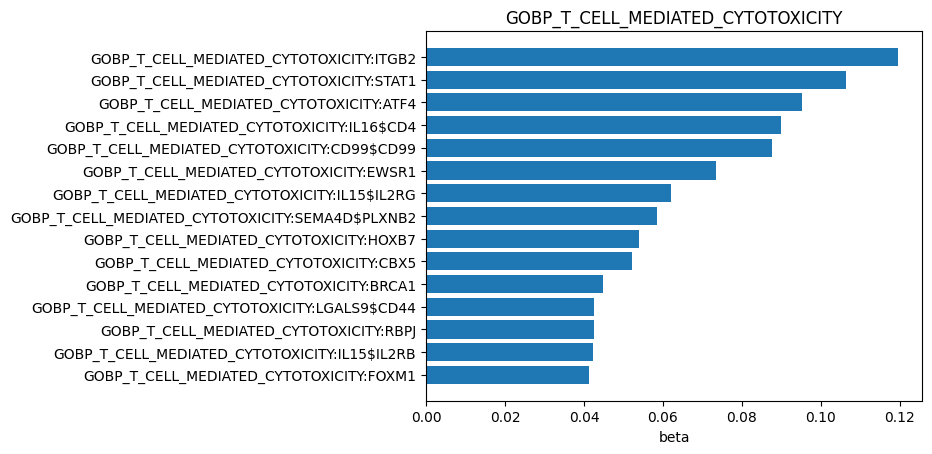

In [19]:
res_tcyto, sub_tcyto = run_signature('GOBP_T_CELL_MEDIATED_CYTOTOXICITY')

=== KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY: 88 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
2233,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,ITGB2,tf,0.661454,0.455060,0.207080,0.711958,9364,0.594289,0.704616,0.621147,0.670978
1875,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,NFATC3,tf,0.285251,0.230807,0.053272,0.711958,9364,0.238104,0.324871,0.258811,0.307217
695,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,LCK$CD8A,lr,0.266826,0.278975,0.077827,0.711958,9364,0.203213,0.358912,0.243737,0.301817
2400,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,EWSR1,tf,0.238085,0.369223,0.136325,0.711958,9364,0.186788,0.300341,0.215266,0.262639
1874,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,NFATC2,tf,0.201893,0.164803,0.027160,0.711958,9364,0.159835,0.245319,0.177397,0.224266
2296,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,NFAT5,tf,0.192813,0.162174,0.026300,0.711958,9364,0.123761,0.239371,0.148910,0.217325
662,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,ICAM1$ITGAL,lr,0.188977,0.278579,0.077606,0.711958,9364,0.146848,0.223026,0.167426,0.206492
2123,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,IKZF1,tf,0.188291,0.281129,0.079034,0.711958,9364,0.125270,0.237242,0.157162,0.212524
420,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,FASLG$FAS,lr,0.167863,0.196753,0.038712,0.711958,9364,0.128222,0.225318,0.146713,0.198612
2125,KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,IKZF3,tf,0.158359,0.215639,0.046500,0.711958,9364,0.114461,0.201932,0.137774,0.183365


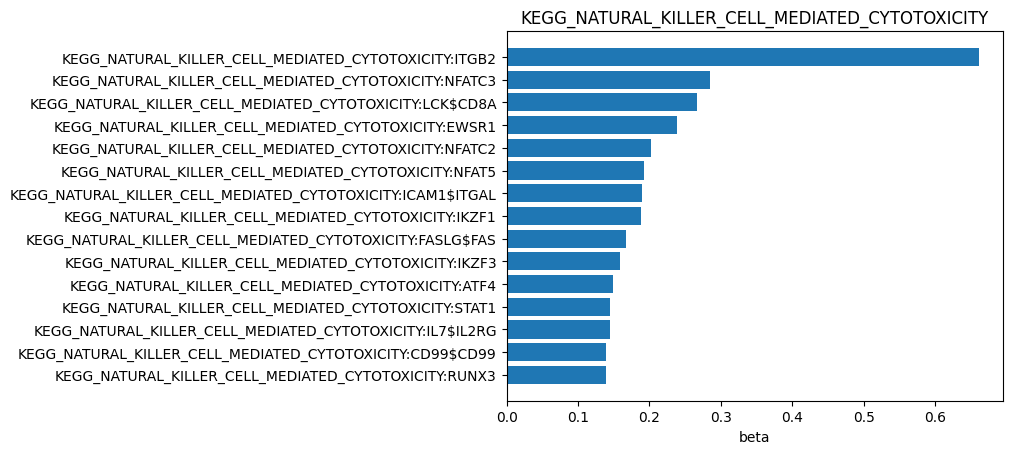

In [20]:
res_nk, sub_nk = run_signature('KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY')

=== HALLMARK_TNFA_SIGNALING_VIA_NFKB: 109 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
42,HALLMARK_TNFA_SIGNALING_VIA_NFKB,IRF1,tf,0.541737,0.394635,0.155736,0.778264,9364,0.454070,0.554636,0.497130,0.546542
514,HALLMARK_TNFA_SIGNALING_VIA_NFKB,LGALS9$CD44,lr,0.388063,0.420907,0.177162,0.778264,9364,0.304501,0.394685,0.321502,0.364009
2186,HALLMARK_TNFA_SIGNALING_VIA_NFKB,NFE2L2,tf,0.330967,0.338177,0.114364,0.778264,9364,0.255420,0.347890,0.285210,0.326417
426,HALLMARK_TNFA_SIGNALING_VIA_NFKB,TNFSF9$TNFRSF9,lr,0.263091,0.253048,0.064033,0.778264,9364,0.170549,0.330241,0.216162,0.277429
672,HALLMARK_TNFA_SIGNALING_VIA_NFKB,ITGB2$ICAM1,lr,0.252639,0.299299,0.089580,0.778264,9364,0.164295,0.280728,0.202782,0.257183
1120,HALLMARK_TNFA_SIGNALING_VIA_NFKB,RELA,tf,0.238241,0.256042,0.065558,0.778264,9364,0.182034,0.275107,0.214844,0.255996
61,HALLMARK_TNFA_SIGNALING_VIA_NFKB,NFKB2,tf,0.216890,0.225392,0.050801,0.778264,9364,0.149599,0.243593,0.185358,0.221330
410,HALLMARK_TNFA_SIGNALING_VIA_NFKB,IFNG$IFNGR2,lr,0.192859,0.250472,0.062736,0.778264,9364,0.104781,0.260984,0.150860,0.225793
94,HALLMARK_TNFA_SIGNALING_VIA_NFKB,STAT1,tf,0.191336,0.386292,0.149222,0.778264,9364,0.108093,0.184771,0.128954,0.164169
1649,HALLMARK_TNFA_SIGNALING_VIA_NFKB,STAT5A,tf,0.176253,0.187973,0.035334,0.778264,9364,0.125131,0.230587,0.158142,0.191432


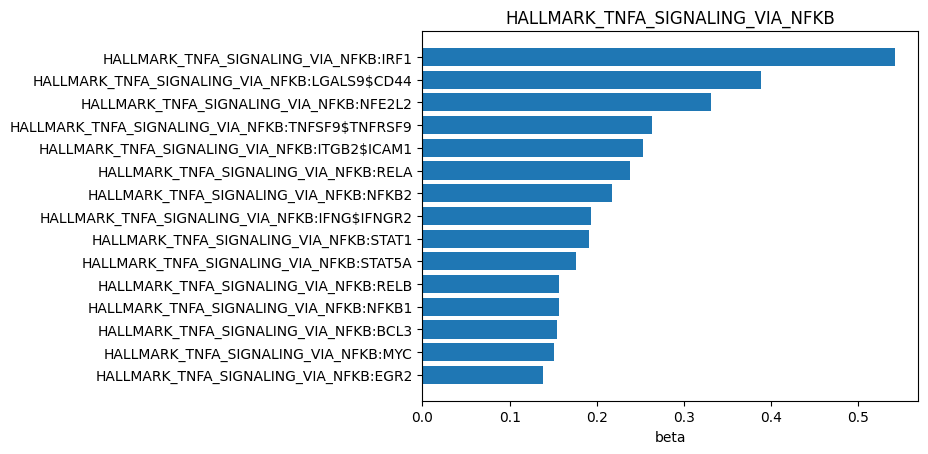

In [21]:
res_tnfa, sub_tnfa = run_signature('HALLMARK_TNFA_SIGNALING_VIA_NFKB')

=== HALLMARK_INTERFERON_GAMMA_RESPONSE: 95 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
139,HALLMARK_INTERFERON_GAMMA_RESPONSE,STAT1,tf,0.561143,0.438077,0.191911,0.690299,9364,0.379786,0.596504,0.469497,0.538488
2264,HALLMARK_INTERFERON_GAMMA_RESPONSE,HIF1A,tf,0.338044,0.247557,0.061284,0.690299,9364,0.254784,0.392471,0.306391,0.367038
64,HALLMARK_INTERFERON_GAMMA_RESPONSE,IRF1,tf,0.272055,0.308167,0.094967,0.690299,9364,0.198769,0.318690,0.229918,0.283272
2189,HALLMARK_INTERFERON_GAMMA_RESPONSE,EWSR1,tf,0.252911,0.355233,0.126190,0.690299,9364,0.155871,0.283981,0.202889,0.255176
1723,HALLMARK_INTERFERON_GAMMA_RESPONSE,ITGB2,tf,0.252042,0.361305,0.130541,0.690299,9364,0.165932,0.311383,0.200690,0.263389
724,HALLMARK_INTERFERON_GAMMA_RESPONSE,ITGB2$ICAM1,lr,0.251409,0.273680,0.074901,0.690299,9364,0.108117,0.318224,0.201324,0.269598
389,HALLMARK_INTERFERON_GAMMA_RESPONSE,IL15$IL2RB,lr,0.231513,0.264218,0.069811,0.690299,9364,0.108219,0.279341,0.161372,0.224373
566,HALLMARK_INTERFERON_GAMMA_RESPONSE,LGALS9$CD44,lr,0.227301,0.347305,0.120621,0.690299,9364,0.070535,0.238825,0.126804,0.191003
443,HALLMARK_INTERFERON_GAMMA_RESPONSE,IL16$CD4,lr,0.186860,0.266528,0.071037,0.690299,9364,0.075519,0.247229,0.097624,0.183155
2080,HALLMARK_INTERFERON_GAMMA_RESPONSE,HOXB7,tf,0.184445,0.289304,0.083697,0.690299,9364,0.080906,0.239236,0.154843,0.219736


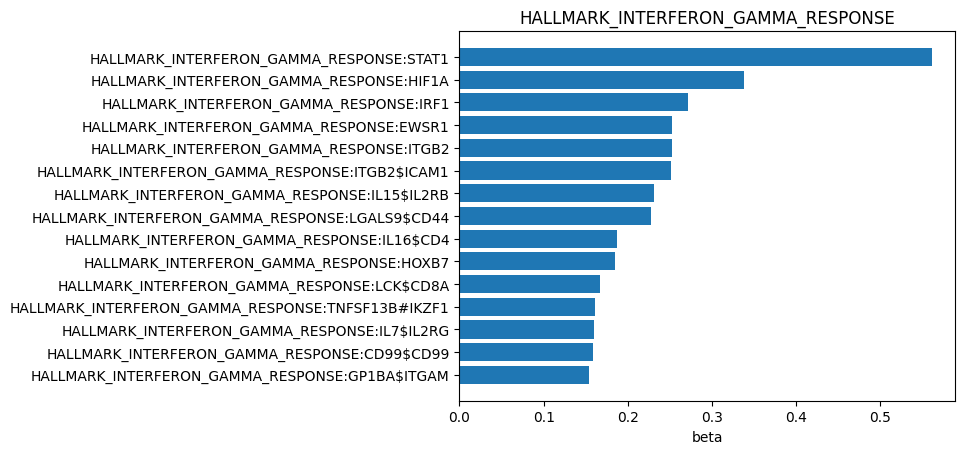

In [22]:
res_ifng, sub_ifng = run_signature('HALLMARK_INTERFERON_GAMMA_RESPONSE')   # positive control

## Metabolic

=== HALLMARK_OXIDATIVE_PHOSPHORYLATION: 45 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
1119,HALLMARK_OXIDATIVE_PHOSPHORYLATION,HMGA1,tf,0.205015,0.360074,0.129653,0.656191,9364,0.131872,0.236422,0.144389,0.202991
1514,HALLMARK_OXIDATIVE_PHOSPHORYLATION,ATF4,tf,0.187920,0.367380,0.134968,0.656191,9364,0.118765,0.212260,0.146285,0.199178
1964,HALLMARK_OXIDATIVE_PHOSPHORYLATION,MYBL2,tf,0.182821,0.301017,0.090611,0.656191,9364,0.084994,0.223648,0.137188,0.194517
101,HALLMARK_OXIDATIVE_PHOSPHORYLATION,TFAP2A,tf,0.166753,0.318194,0.101247,0.656191,9364,0.097104,0.207973,0.116918,0.162200
2067,HALLMARK_OXIDATIVE_PHOSPHORYLATION,EWSR1,tf,0.164311,0.335760,0.112735,0.656191,9364,0.102750,0.187508,0.131646,0.176927
2240,HALLMARK_OXIDATIVE_PHOSPHORYLATION,SOX10,tf,0.145377,0.326997,0.106927,0.656191,9364,0.073576,0.166799,0.093688,0.140784
640,HALLMARK_OXIDATIVE_PHOSPHORYLATION,CD99$CD99,lr,0.143720,0.346924,0.120356,0.656191,9364,0.087803,0.176761,0.105914,0.154295
95,HALLMARK_OXIDATIVE_PHOSPHORYLATION,STAT1,tf,0.133272,0.348176,0.121226,0.656191,9364,0.077684,0.161203,0.090814,0.131677
1306,HALLMARK_OXIDATIVE_PHOSPHORYLATION,TRIM28,tf,0.132095,0.267327,0.071464,0.656191,9364,0.070923,0.176498,0.095798,0.144020
1258,HALLMARK_OXIDATIVE_PHOSPHORYLATION,BRCA1,tf,0.130437,0.244603,0.059830,0.656191,9364,0.059836,0.173985,0.090025,0.142357


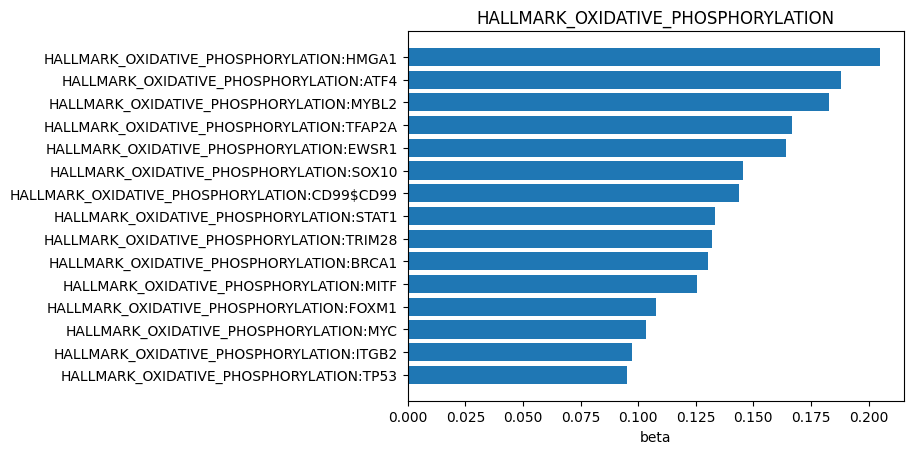

In [15]:
res_oxphos, sub_oxphos = run_signature('HALLMARK_OXIDATIVE_PHOSPHORYLATION')

=== HALLMARK_GLYCOLYSIS: 74 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
468,HALLMARK_GLYCOLYSIS,LGALS9$CD44,lr,0.319167,0.385082,0.148288,0.726705,9364,0.247413,0.349872,0.293675,0.335351
594,HALLMARK_GLYCOLYSIS,CD99$CD99,lr,0.234670,0.384821,0.148088,0.726705,9364,0.168876,0.265963,0.196716,0.232720
1672,HALLMARK_GLYCOLYSIS,ATF4,tf,0.217472,0.382732,0.146484,0.726705,9364,0.169551,0.258032,0.185987,0.223837
1731,HALLMARK_GLYCOLYSIS,FOXM1,tf,0.199894,0.313699,0.098407,0.726705,9364,0.125570,0.259563,0.156564,0.210997
1616,HALLMARK_GLYCOLYSIS,MYBL2,tf,0.196394,0.301606,0.090966,0.726705,9364,0.111052,0.233985,0.168433,0.222880
279,HALLMARK_GLYCOLYSIS,CXCL12$CXCR4,lr,0.190405,0.134846,0.018184,0.726705,9364,0.139996,0.220140,0.158958,0.196523
2277,HALLMARK_GLYCOLYSIS,HOXB7,tf,0.189080,0.326537,0.106626,0.726705,9364,0.119477,0.238592,0.159087,0.217266
1502,HALLMARK_GLYCOLYSIS,EWSR1,tf,0.186375,0.347055,0.120447,0.726705,9364,0.143742,0.219958,0.162270,0.197296
1930,HALLMARK_GLYCOLYSIS,SOX10,tf,0.167403,0.340788,0.116136,0.726705,9364,0.088366,0.196686,0.104154,0.162755
545,HALLMARK_GLYCOLYSIS,LAMC1$CD44,lr,0.157913,0.343948,0.118300,0.726705,9364,0.091659,0.189030,0.120459,0.168694


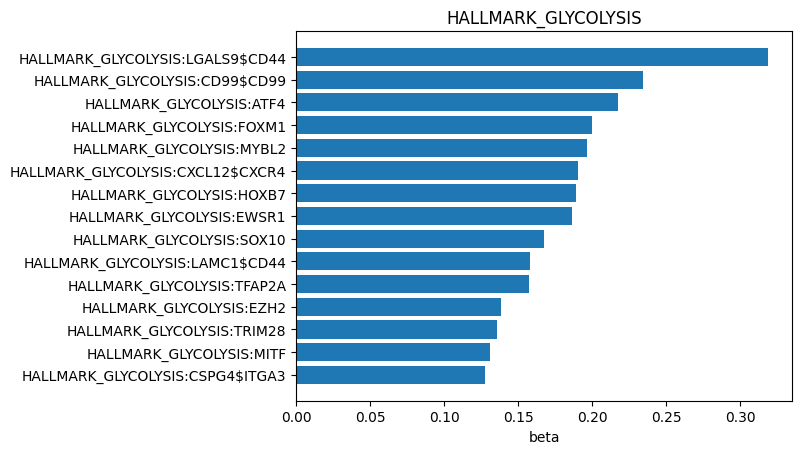

In [9]:
res_glyc, sub_glyc = run_signature('HALLMARK_GLYCOLYSIS')

=== HALLMARK_HYPOXIA: 96 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
838,HALLMARK_HYPOXIA,ETS1,tf,0.322687,0.276334,0.076360,0.678983,9364,0.279272,0.357905,0.304561,0.338294
1226,HALLMARK_HYPOXIA,RBPJ,tf,0.249848,0.282276,0.079680,0.678983,9364,0.198105,0.282844,0.211273,0.263939
575,HALLMARK_HYPOXIA,CD99$CD99,lr,0.186658,0.349952,0.122466,0.678983,9364,0.128296,0.204461,0.144237,0.190580
832,HALLMARK_HYPOXIA,ATF4,tf,0.183296,0.353114,0.124690,0.678983,9364,0.107794,0.208760,0.149765,0.186745
851,HALLMARK_HYPOXIA,NR3C1,tf,0.158309,0.161146,0.025968,0.678983,9364,0.117506,0.218431,0.129010,0.161861
1438,HALLMARK_HYPOXIA,EWSR1,tf,0.155710,0.337736,0.114066,0.678983,9364,0.106960,0.207103,0.130448,0.175268
262,HALLMARK_HYPOXIA,CXCL12$CXCR4,lr,0.136500,0.135710,0.018417,0.678983,9364,0.100366,0.179493,0.117106,0.158378
1962,HALLMARK_HYPOXIA,ITGB2,tf,0.132040,0.298533,0.089122,0.678983,9364,0.049687,0.133081,0.075741,0.122099
1212,HALLMARK_HYPOXIA,FOXO3,tf,0.131735,0.144303,0.020823,0.678983,9364,0.092169,0.167841,0.116575,0.148170
2031,HALLMARK_HYPOXIA,HOXB7,tf,0.129511,0.306566,0.093983,0.678983,9364,0.092775,0.183924,0.116528,0.156428


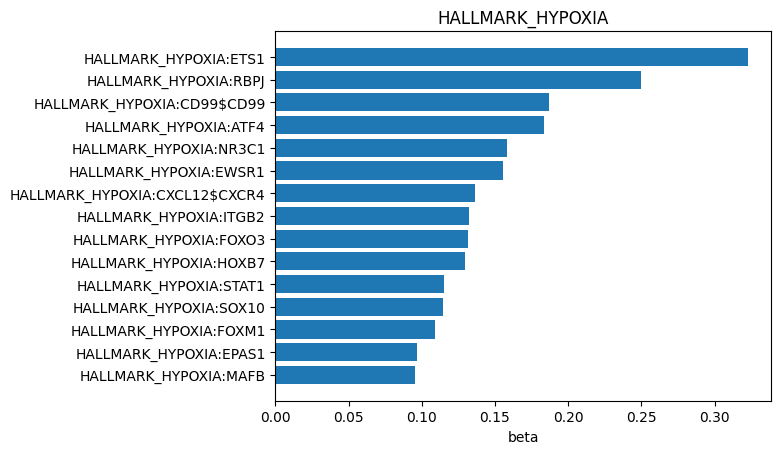

In [10]:
res_hyp, sub_hyp = run_signature('HALLMARK_HYPOXIA')

=== HALLMARK_FATTY_ACID_METABOLISM: 47 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
1836,HALLMARK_FATTY_ACID_METABOLISM,SOX10,tf,0.137307,0.328220,0.107729,0.543261,9364,0.085666,0.162071,0.096891,0.135946
2240,HALLMARK_FATTY_ACID_METABOLISM,ATF4,tf,0.117781,0.336422,0.113180,0.543261,9364,0.065698,0.139975,0.089192,0.120309
101,HALLMARK_FATTY_ACID_METABOLISM,TFAP2A,tf,0.110213,0.307337,0.094456,0.543261,9364,0.069151,0.128281,0.088336,0.118748
1115,HALLMARK_FATTY_ACID_METABOLISM,MYBL2,tf,0.106556,0.267057,0.071319,0.543261,9364,0.056515,0.132781,0.080443,0.119018
2008,HALLMARK_FATTY_ACID_METABOLISM,HMGA1,tf,0.105177,0.324397,0.105233,0.543261,9364,0.037933,0.119228,0.072156,0.106877
640,HALLMARK_FATTY_ACID_METABOLISM,CD99$CD99,lr,0.100067,0.325345,0.105849,0.543261,9364,0.061962,0.116164,0.073421,0.097012
95,HALLMARK_FATTY_ACID_METABOLISM,STAT1,tf,0.092296,0.326923,0.106879,0.543261,9364,0.053213,0.116136,0.065706,0.095105
2184,HALLMARK_FATTY_ACID_METABOLISM,EWSR1,tf,0.074580,0.291901,0.085206,0.543261,9364,0.032379,0.101394,0.061154,0.082979
1211,HALLMARK_FATTY_ACID_METABOLISM,HOXB7,tf,0.072073,0.298237,0.088945,0.543261,9364,0.057742,0.101474,0.067635,0.092513
1515,HALLMARK_FATTY_ACID_METABOLISM,TRIM28,tf,0.071693,0.240331,0.057759,0.543261,9364,0.033933,0.113935,0.044963,0.080239


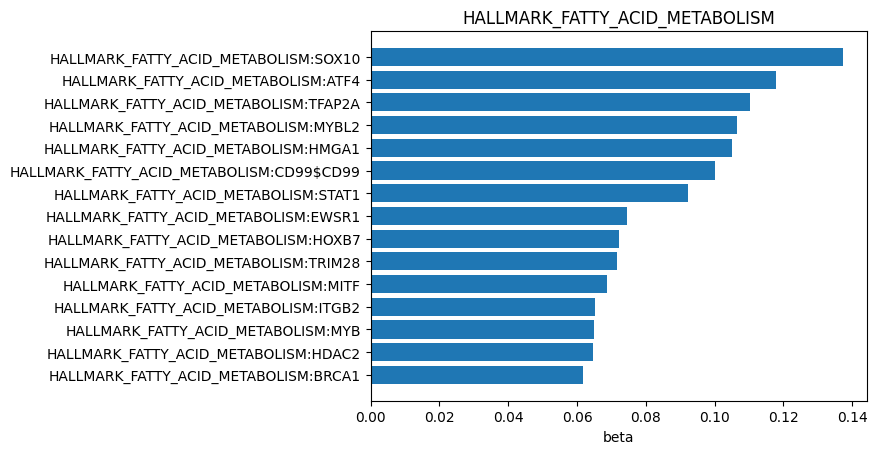

In [11]:
res_fao, sub_fao = run_signature('HALLMARK_FATTY_ACID_METABOLISM')

=== HALLMARK_MTORC1_SIGNALING: 91 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
2373,HALLMARK_MTORC1_SIGNALING,ITGB2,tf,0.687642,0.387232,0.149948,0.777188,9364,0.562591,0.679985,0.600289,0.668109
59,HALLMARK_MTORC1_SIGNALING,MYBL2,tf,0.436919,0.350010,0.122507,0.777188,9364,0.300792,0.519815,0.354231,0.449012
1460,HALLMARK_MTORC1_SIGNALING,XBP1,tf,0.344786,0.190396,0.036251,0.777188,9364,0.281356,0.387707,0.298726,0.350506
1832,HALLMARK_MTORC1_SIGNALING,HMGA1,tf,0.310030,0.375027,0.140646,0.777188,9364,0.185977,0.328378,0.228914,0.293062
2043,HALLMARK_MTORC1_SIGNALING,FOXM1,tf,0.294370,0.329000,0.108241,0.777188,9364,0.202842,0.367993,0.245391,0.320421
1323,HALLMARK_MTORC1_SIGNALING,HOXB7,tf,0.262521,0.330940,0.109521,0.777188,9364,0.132331,0.327611,0.211455,0.298059
1607,HALLMARK_MTORC1_SIGNALING,ATF4,tf,0.260628,0.381740,0.145726,0.777188,9364,0.155425,0.288034,0.205185,0.260842
656,HALLMARK_MTORC1_SIGNALING,CD99$CD99,lr,0.257545,0.364399,0.132787,0.777188,9364,0.147647,0.311011,0.191293,0.243480
2009,HALLMARK_MTORC1_SIGNALING,EWSR1,tf,0.238089,0.364037,0.132523,0.777188,9364,0.174078,0.275018,0.204561,0.243525
116,HALLMARK_MTORC1_SIGNALING,TRIM28,tf,0.225467,0.284776,0.081097,0.777188,9364,0.123485,0.270355,0.159536,0.243241


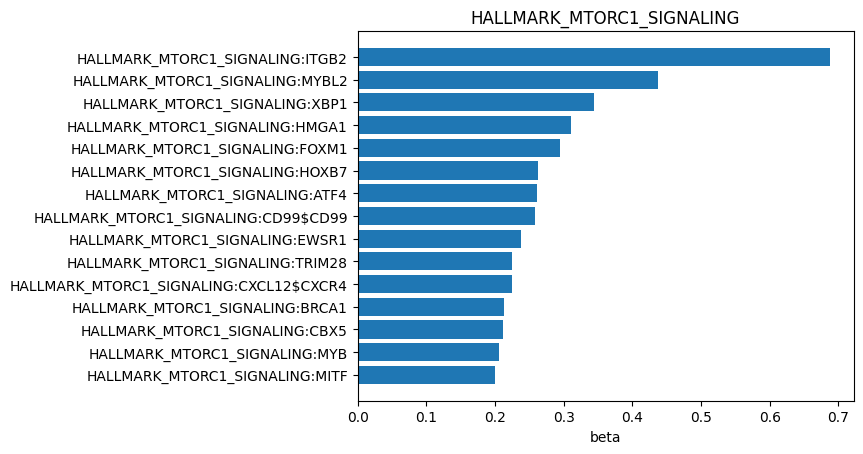

In [12]:
res_mtor, sub_mtor = run_signature('HALLMARK_MTORC1_SIGNALING')

## Negative control

=== HALLMARK_PANCREAS_BETA_CELLS: 18 genes present ===


,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
1088,HALLMARK_PANCREAS_BETA_CELLS,MAFB,tf,0.120067,0.480558,2.309355e-01,0.433086,9364,0.107340,0.136217,0.115871,0.125801
2107,HALLMARK_PANCREAS_BETA_CELLS,FOXO1,tf,0.075560,0.353199,1.247499e-01,0.433086,9364,0.065506,0.083982,0.070835,0.081401
1324,HALLMARK_PANCREAS_BETA_CELLS,VDR,tf,0.073581,0.360498,1.299587e-01,0.433086,9364,0.060049,0.085040,0.067580,0.079726
1976,HALLMARK_PANCREAS_BETA_CELLS,LMO2,tf,0.017690,0.205470,4.221792e-02,0.433086,9364,0.009455,0.029385,0.013399,0.022690
1443,HALLMARK_PANCREAS_BETA_CELLS,FGF4#PDX1,ltf,0.000000,0.000000,0.000000e+00,0.433086,9364,0.000000,0.000000,0.000000,0.000000
1445,HALLMARK_PANCREAS_BETA_CELLS,TGFB1#PPARA,ltf,0.000000,-0.000415,1.718951e-07,0.433086,9364,-0.000000,-0.000000,0.000000,0.000000
1446,HALLMARK_PANCREAS_BETA_CELLS,MSTN#PPARA,ltf,0.000000,0.008390,7.039559e-05,0.433086,9364,0.000000,0.000000,0.000000,0.000000
1447,HALLMARK_PANCREAS_BETA_CELLS,TNF#PPARA,ltf,-0.000000,0.001127,1.269154e-06,0.433086,9364,-0.000000,-0.000000,0.000000,0.000000
1448,HALLMARK_PANCREAS_BETA_CELLS,EGF#PPARA,ltf,0.000000,-0.000570,3.250682e-07,0.433086,9364,0.000000,0.000000,0.000000,0.000000
1449,HALLMARK_PANCREAS_BETA_CELLS,TNF#PPARD,ltf,0.000000,0.024354,5.931147e-04,0.433086,9364,0.000000,0.000000,0.000000,0.000000


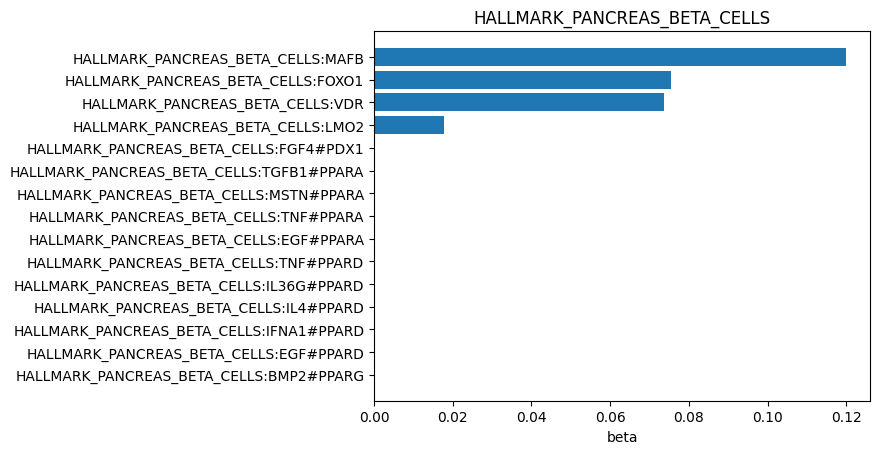

In [13]:
res_neg, sub_neg = run_signature('HALLMARK_PANCREAS_BETA_CELLS')

## Distribution of a single factor (edit the signature / factor)

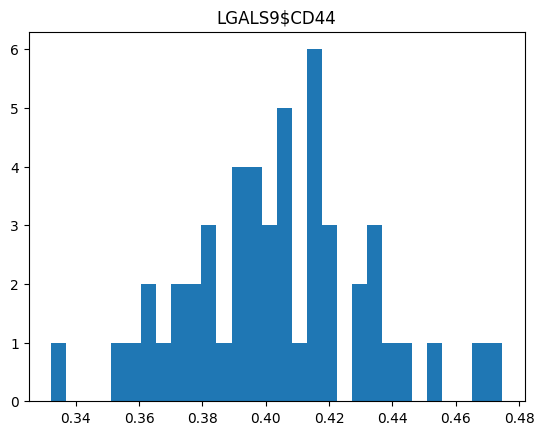

In [12]:
sub = sub_il2                 # <- any signature's resample output from above
FACTOR = 'LGALS9$CD44' # <- any factor name (tf / lig$rec / lig#tf / metab@name)
plot_beta_histogram(sub[FACTOR], title=FACTOR);

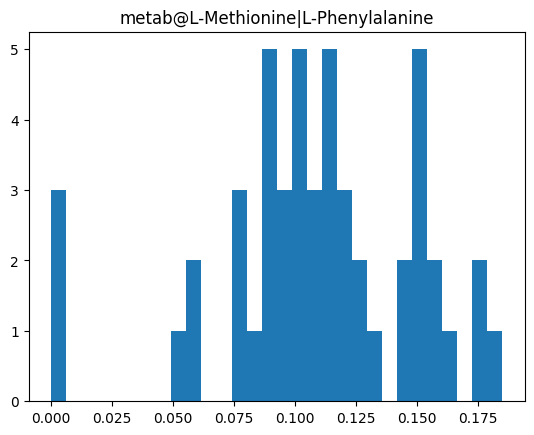

In [13]:
sub = sub_il2                 # <- any signature's resample output from above
FACTOR = 'metab@L-Methionine|L-Phenylalanine' # <- any factor name (tf / lig$rec / lig#tf / metab@name)
plot_beta_histogram(sub[FACTOR], title=FACTOR);

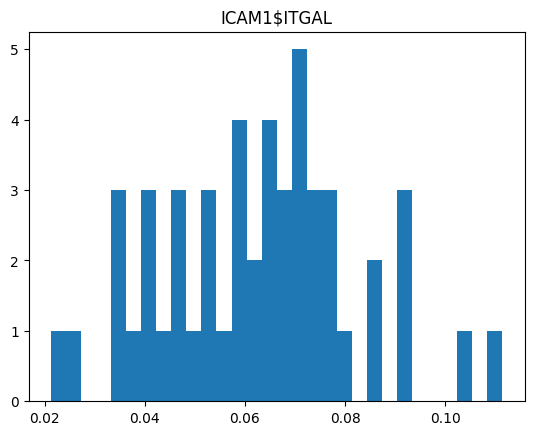

In [14]:
sub = sub_il2                 # <- any signature's resample output from above
FACTOR = 'ICAM1$ITGAL' # <- any factor name (tf / lig$rec / lig#tf / metab@name)
plot_beta_histogram(sub[FACTOR], title=FACTOR);